---
## 1. Initialization

Memuat seluruh library yang diperlukan dan mendefinisikan path direktori.  
Variabel path ditulis sebagai konstanta (UPPER_CASE) sesuai konvensi clean code.

In [1]:
import pandas as pd
import numpy as np
import os
import cv2
import hashlib
import shutil
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

BASE_DIR = Path(r'd:\Dicoding Academy\DataCapstone')
RAW_DIR = BASE_DIR / 'data_mentah' / 'Data Gambar Makanan Indonesia'
OUTPUT_DIR = BASE_DIR / 'data_output'
YOLO_DIR = OUTPUT_DIR / 'yolo_dataset'

SPLIT_NAMES = ['train', 'valid', 'test']
YOLO_SPLIT_MAP = {'train': 'train', 'valid': 'val', 'test': 'test'}

for subdirectory in ['images/train', 'images/val', 'images/test',
                     'labels/train', 'labels/val', 'labels/test']:
    (YOLO_DIR / subdirectory).mkdir(parents=True, exist_ok=True)

print("Setup selesai.")

Setup selesai.


---
## 2. Exploratory Data Analysis

### 2.1 Load dan Inspeksi Anotasi

Memuat file `_annotations.csv` dari setiap split (train/valid/test),  
lalu menggabungkannya menjadi satu DataFrame untuk analisis menyeluruh.

In [2]:
def load_annotations(raw_directory, split_names):
    """Memuat dan menggabungkan CSV anotasi dari semua split."""
    dataframes = []
    for split_name in split_names:
        csv_path = raw_directory / split_name / '_annotations.csv'
        annotations = pd.read_csv(csv_path)
        annotations['split'] = split_name
        dataframes.append(annotations)
    return pd.concat(dataframes, ignore_index=True)

annotations_all = load_annotations(RAW_DIR, SPLIT_NAMES)

for split_name in SPLIT_NAMES:
    split_data = annotations_all[annotations_all['split'] == split_name]
    unique_images = split_data['filename'].nunique()
    total_annotations = len(split_data)
    print(f"{split_name:>6}: {unique_images:>5} gambar, {total_annotations:>5} anotasi")

print(f"\nTotal kelas: {annotations_all['class'].nunique()}")
print(f"Daftar kelas: {sorted(annotations_all['class'].unique())}")

 train:  2770 gambar,  4535 anotasi
 valid:   680 gambar,  1109 anotasi
  test:   270 gambar,   478 anotasi

Total kelas: 29
Daftar kelas: ['Apel', 'Ayam Goreng', 'Bakso', 'Biskuit Choco Chips', 'Burger', 'Capcay', 'Donat', 'Ikan Goreng', 'Kentang Goreng', 'Kiwi', 'Mie Goreng', 'Nanas', 'Nasi Goreng', 'Nasi Putih', 'Nugget', 'Pempek', 'Pisang', 'Pizza', 'Rendang Sapi', 'Sate', 'Spaghetti', 'Steak', 'Stroberi', 'Tahu Goreng', 'Telur Goreng', 'Telur Rebus', 'Tempe Goreng', 'Terong Balado', 'Tumis Kangkung']


### 2.2 Distribusi Kelas

Visualisasi jumlah anotasi per kelas untuk mengidentifikasi ketidakseimbangan (imbalance).  
Kelas dengan jumlah anotasi sangat sedikit berpotensi menghasilkan performa model yang rendah.

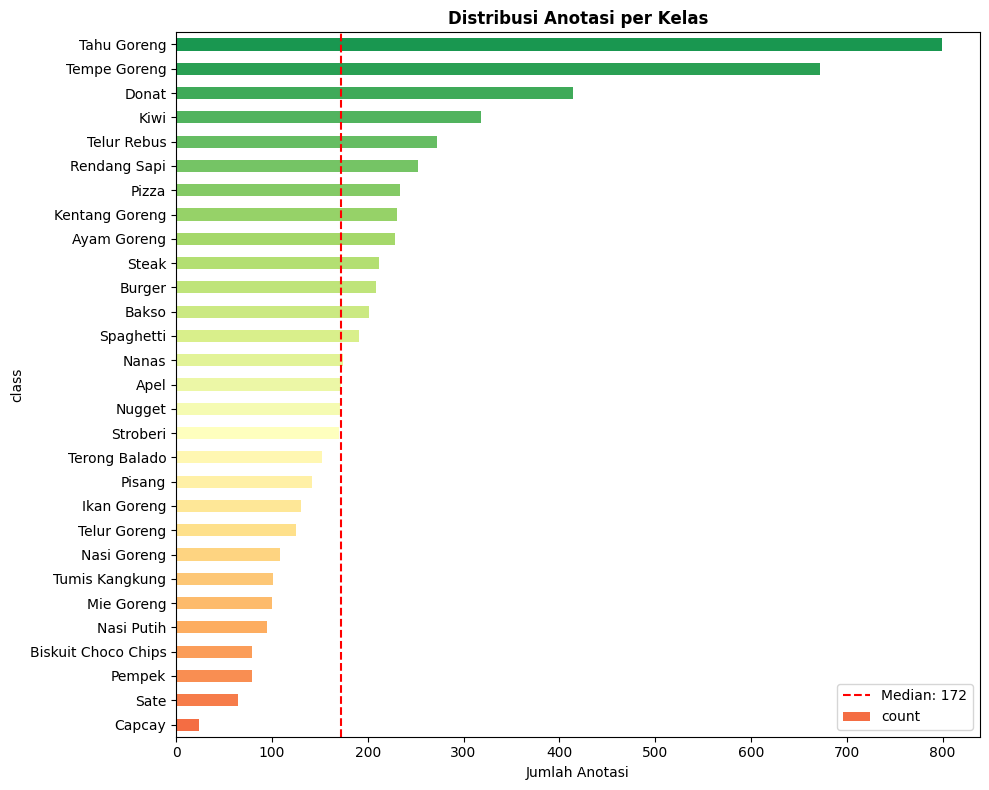

Imbalance ratio: 33.3x
Kelas terbanyak : Tahu Goreng (799)
Kelas tersedikit: Capcay (24)


In [3]:
class_counts = annotations_all['class'].value_counts().sort_values()
imbalance_ratio = class_counts.max() / class_counts.min()

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts)))
class_counts.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Distribusi Anotasi per Kelas', fontweight='bold')
ax.set_xlabel('Jumlah Anotasi')
ax.axvline(x=class_counts.median(), color='red', linestyle='--', label=f'Median: {class_counts.median():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Imbalance ratio: {imbalance_ratio:.1f}x")
print(f"Kelas terbanyak : {class_counts.idxmax()} ({class_counts.max()})")
print(f"Kelas tersedikit: {class_counts.idxmin()} ({class_counts.min()})")

### 2.3 Analisis Bounding Box

Menganalisis properti bounding box: distribusi area, aspect ratio,  
dan jumlah objek per gambar. Informasi ini penting untuk menentukan  
parameter augmentasi dan ukuran input model.

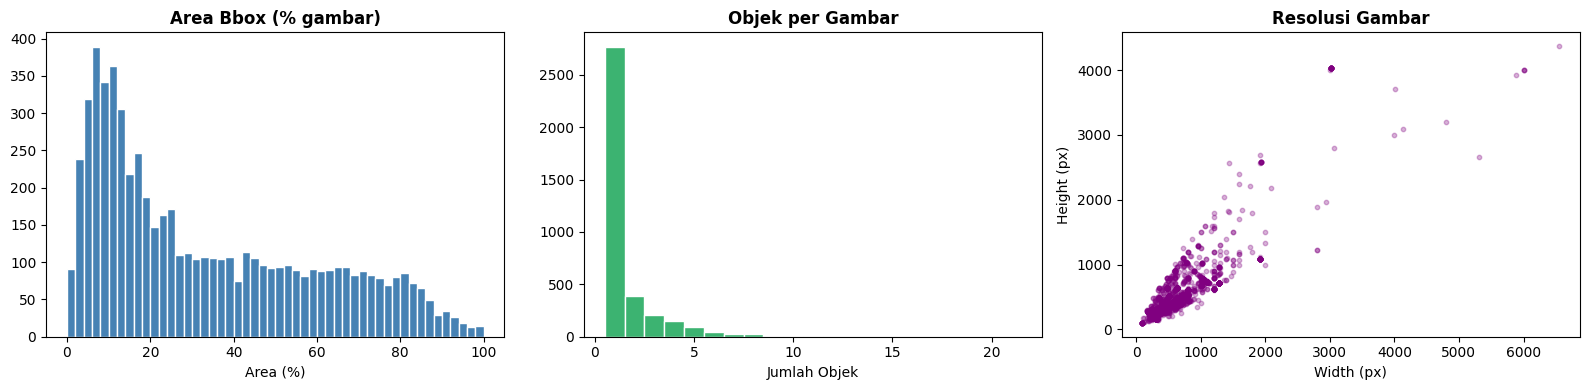

Rata-rata area bbox : 33.3%
Objek per gambar    : min=1, max=21, mean=1.6


In [4]:
annotations_all['bbox_width'] = annotations_all['xmax'] - annotations_all['xmin']
annotations_all['bbox_height'] = annotations_all['ymax'] - annotations_all['ymin']
annotations_all['bbox_area_pct'] = (
    (annotations_all['bbox_width'] * annotations_all['bbox_height'])
    / (annotations_all['width'] * annotations_all['height']) * 100
)
objects_per_image = annotations_all.groupby('filename').size()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(annotations_all['bbox_area_pct'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Area Bbox (% gambar)', fontweight='bold')
axes[0].set_xlabel('Area (%)')

axes[1].hist(objects_per_image.values, bins=range(1, objects_per_image.max() + 2),
             color='mediumseagreen', edgecolor='white', align='left')
axes[1].set_title('Objek per Gambar', fontweight='bold')
axes[1].set_xlabel('Jumlah Objek')

image_sizes = annotations_all.groupby('filename')[['width', 'height']].first()
axes[2].scatter(image_sizes['width'], image_sizes['height'], alpha=0.3, s=10, c='purple')
axes[2].set_title('Resolusi Gambar', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'docs' / 'eda_bbox_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Rata-rata area bbox : {annotations_all['bbox_area_pct'].mean():.1f}%")
print(f"Objek per gambar    : min={objects_per_image.min()}, max={objects_per_image.max()}, mean={objects_per_image.mean():.1f}")

---
## 3. Data Cleaning

### 3.1 Hapus Bounding Box yang Tidak Valid

Bounding box dianggap tidak valid apabila `xmin >= xmax` atau `ymin >= ymax`,  
karena menghasilkan area nol atau negatif yang akan menyebabkan error saat training.

In [5]:
def find_invalid_bboxes(annotations):
    """Identifikasi baris dengan bounding box tidak valid."""
    invalid_mask = (
        (annotations['xmin'] >= annotations['xmax'])
        | (annotations['ymin'] >= annotations['ymax'])
    )
    return invalid_mask

invalid_mask = find_invalid_bboxes(annotations_all)
invalid_rows = annotations_all[invalid_mask]

print(f"Bounding box tidak valid: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    print(invalid_rows[['filename', 'class', 'xmin', 'ymin', 'xmax', 'ymax']].to_string(index=False))

annotations_clean = annotations_all[~invalid_mask].copy()
print(f"\nSisa anotasi setelah cleaning: {len(annotations_clean)}")

Bounding box tidak valid: 2
                                               filename        class  xmin  ymin  xmax  ymax
download-4-_jpg.rf.acc434d8468c6e1d3166ce9167733cf4.jpg Telur Goreng   222   163   223   163
 donuts_599_jpg.rf.bcc7fd9ef1741defc28f92307681c1da.jpg        Donat    21    53    23    53

Sisa anotasi setelah cleaning: 6120


### 3.2 Validasi Integritas Gambar

Memastikan setiap file gambar yang direferensikan dalam CSV benar-benar ada  
dan dapat dibuka tanpa error (tidak corrupt atau terpotong).

In [6]:
def validate_image_integrity(annotations, raw_directory):
    """Periksa apakah semua gambar dapat dibuka tanpa error."""
    corrupt_files = []
    valid_count = 0

    for split_name in annotations['split'].unique():
        split_dir = raw_directory / split_name
        image_files = annotations[annotations['split'] == split_name]['filename'].unique()

        for image_file in image_files:
            image_path = split_dir / image_file
            if not image_path.exists():
                corrupt_files.append(image_file)
                continue
            try:
                img = Image.open(image_path)
                img.verify()
                valid_count += 1
            except Exception:
                corrupt_files.append(image_file)

    return valid_count, corrupt_files

valid_count, corrupt_files = validate_image_integrity(annotations_clean, RAW_DIR)
print(f"Gambar valid  : {valid_count}")
print(f"Gambar corrupt: {len(corrupt_files)}")

if corrupt_files:
    annotations_clean = annotations_clean[~annotations_clean['filename'].isin(corrupt_files)]

Gambar valid  : 3720
Gambar corrupt: 0


### 3.3 Deteksi Duplikat Gambar

Menggunakan MD5 hash untuk mendeteksi file gambar yang identik secara binary.  
Duplikat antar split dapat menyebabkan data leakage.

In [7]:
def compute_file_hash(filepath):
    """Hitung MD5 hash dari sebuah file."""
    hasher = hashlib.md5()
    with open(filepath, 'rb') as file_handle:
        for chunk in iter(lambda: file_handle.read(8192), b''):
            hasher.update(chunk)
    return hasher.hexdigest()

def find_duplicate_images(annotations, raw_directory):
    """Identifikasi gambar duplikat berdasarkan hash."""
    hash_registry = {}
    duplicates = []

    for split_name in annotations['split'].unique():
        split_dir = raw_directory / split_name
        image_files = annotations[annotations['split'] == split_name]['filename'].unique()

        for image_file in image_files:
            image_path = split_dir / image_file
            if not image_path.exists():
                continue
            file_hash = compute_file_hash(image_path)
            if file_hash in hash_registry:
                duplicates.append((split_name, image_file, hash_registry[file_hash]))
            else:
                hash_registry[file_hash] = (split_name, image_file)

    return duplicates

duplicate_images = find_duplicate_images(annotations_clean, RAW_DIR)
print(f"Duplikat ditemukan: {len(duplicate_images)}")

Duplikat ditemukan: 102


### 3.4 Ringkasan Cleaning

In [8]:
print("Ringkasan setelah cleaning:")
for split_name in SPLIT_NAMES:
    split_data = annotations_clean[annotations_clean['split'] == split_name]
    print(f"  {split_name:>6}: {split_data['filename'].nunique()} gambar, {len(split_data)} anotasi")
print(f"  Total : {annotations_clean['filename'].nunique()} gambar, {len(annotations_clean)} anotasi")

Ringkasan setelah cleaning:
   train: 2770 gambar, 4533 anotasi
   valid: 680 gambar, 1109 anotasi
    test: 270 gambar, 478 anotasi
  Total : 3720 gambar, 6120 anotasi


---
## 4. Data Wrangling — Konversi ke Format YOLO

### 4.1 Class Mapping

Membuat pemetaan nama kelas ke integer ID (urut alfabetis).  
YOLO membutuhkan class ID numerik, bukan string.

In [9]:
class_names = sorted(annotations_clean['class'].unique())
class_to_id = {name: idx for idx, name in enumerate(class_names)}

print(f"Total kelas: {len(class_names)}\n")
for class_name, class_id in class_to_id.items():
    count = len(annotations_clean[annotations_clean['class'] == class_name])
    print(f"  {class_id:>2} -> {class_name} ({count})")

Total kelas: 29

   0 -> Apel (172)
   1 -> Ayam Goreng (229)
   2 -> Bakso (201)
   3 -> Biskuit Choco Chips (79)
   4 -> Burger (209)
   5 -> Capcay (24)
   6 -> Donat (413)
   7 -> Ikan Goreng (130)
   8 -> Kentang Goreng (231)
   9 -> Kiwi (318)
  10 -> Mie Goreng (100)
  11 -> Nanas (174)
  12 -> Nasi Goreng (108)
  13 -> Nasi Putih (95)
  14 -> Nugget (171)
  15 -> Pempek (79)
  16 -> Pisang (142)
  17 -> Pizza (234)
  18 -> Rendang Sapi (253)
  19 -> Sate (65)
  20 -> Spaghetti (191)
  21 -> Steak (212)
  22 -> Stroberi (170)
  23 -> Tahu Goreng (799)
  24 -> Telur Goreng (124)
  25 -> Telur Rebus (272)
  26 -> Tempe Goreng (672)
  27 -> Terong Balado (152)
  28 -> Tumis Kangkung (101)


### 4.2 Konversi Bounding Box: TensorFlow CSV ke YOLO TXT

Format TensorFlow menggunakan koordinat absolut `(xmin, ymin, xmax, ymax)`.  
YOLO membutuhkan format normalized center `(class_id, x_center, y_center, width, height)`  
dimana semua nilai berada dalam rentang [0, 1].

In [10]:
def convert_to_yolo_format(xmin, ymin, xmax, ymax, image_width, image_height):
    """Konversi bbox absolut ke YOLO normalized center format."""
    xmin = max(0, min(xmin, image_width))
    xmax = max(0, min(xmax, image_width))
    ymin = max(0, min(ymin, image_height))
    ymax = max(0, min(ymax, image_height))

    x_center = ((xmin + xmax) / 2.0) / image_width
    y_center = ((ymin + ymax) / 2.0) / image_height
    bbox_width = (xmax - xmin) / image_width
    bbox_height = (ymax - ymin) / image_height

    return x_center, y_center, bbox_width, bbox_height


def export_yolo_dataset(annotations, class_mapping, raw_dir, yolo_dir, split_map):
    """Konversi dan export seluruh dataset ke format YOLO."""
    for split_name, yolo_split in split_map.items():
        split_annotations = annotations[annotations['split'] == split_name]
        source_dir = raw_dir / split_name
        image_destination = yolo_dir / 'images' / yolo_split
        label_destination = yolo_dir / 'labels' / yolo_split

        image_count = 0
        for filename, group in split_annotations.groupby('filename'):
            source_image = source_dir / filename
            if not source_image.exists():
                continue

            destination_image = image_destination / filename
            if not destination_image.exists():
                shutil.copy2(source_image, destination_image)
            image_count += 1

            label_lines = []
            for _, row in group.iterrows():
                x_c, y_c, b_w, b_h = convert_to_yolo_format(
                    row['xmin'], row['ymin'], row['xmax'], row['ymax'],
                    row['width'], row['height']
                )
                if all(0 <= v <= 1 for v in [x_c, y_c, b_w, b_h]) and b_w > 0 and b_h > 0:
                    class_id = class_mapping[row['class']]
                    label_lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {b_w:.6f} {b_h:.6f}")

            if label_lines:
                label_file = label_destination / (Path(filename).stem + '.txt')
                with open(label_file, 'w') as file_handle:
                    file_handle.write('\n'.join(label_lines))

        print(f"  {yolo_split}: {image_count} gambar diproses")

export_yolo_dataset(annotations_clean, class_to_id, RAW_DIR, YOLO_DIR, YOLO_SPLIT_MAP)

  train: 2770 gambar diproses
  val: 680 gambar diproses
  test: 270 gambar diproses


### 4.3 Generate data.yaml

File konfigurasi yang dibutuhkan Ultralytics YOLOv11 untuk membaca dataset.

In [11]:
data_config = {
    'path': str(YOLO_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': len(class_names),
    'names': class_names
}

yaml_path = YOLO_DIR / 'data.yaml'
with open(yaml_path, 'w') as file_handle:
    yaml.dump(data_config, file_handle, default_flow_style=False, sort_keys=False)

print(f"Tersimpan: {yaml_path}")
print(f"nc: {data_config['nc']}")

Tersimpan: d:\Dicoding Academy\DataCapstone\data_output\yolo_dataset\data.yaml
nc: 29


---
## 5. Strategi Augmentasi

Mengidentifikasi kelas-kelas dengan jumlah sampel di bawah ambang minimum.  
Augmentasi dilakukan secara online oleh YOLOv11 saat training,  
sehingga tidak perlu membuat file augmented secara offline.

In [12]:
MINIMUM_SAMPLES_PER_CLASS = 100

train_annotations = annotations_clean[annotations_clean['split'] == 'train']
train_class_counts = train_annotations['class'].value_counts()

minority_classes = train_class_counts[train_class_counts < MINIMUM_SAMPLES_PER_CLASS]

print(f"Target minimum per kelas: {MINIMUM_SAMPLES_PER_CLASS}")
print(f"Kelas di bawah target   : {len(minority_classes)}\n")

for class_name, count in minority_classes.items():
    augmentation_factor = int(np.ceil(MINIMUM_SAMPLES_PER_CLASS / count))
    print(f"  {class_name}: {count} (perlu augmentasi {augmentation_factor}x)")

print("\nRekomendasi parameter training YOLOv11:")
print("  hsv_h=0.015, hsv_s=0.7, hsv_v=0.4")
print("  degrees=10.0, translate=0.1, scale=0.5")
print("  fliplr=0.5, mosaic=1.0, mixup=0.1")
print("  cos_lr=True, close_mosaic=10")

Target minimum per kelas: 100
Kelas di bawah target   : 10

  Stroberi: 94 (perlu augmentasi 2x)
  Nasi Goreng: 88 (perlu augmentasi 2x)
  Mie Goreng: 81 (perlu augmentasi 2x)
  Tumis Kangkung: 81 (perlu augmentasi 2x)
  Nasi Putih: 71 (perlu augmentasi 2x)
  Ikan Goreng: 65 (perlu augmentasi 2x)
  Pempek: 63 (perlu augmentasi 2x)
  Biskuit Choco Chips: 53 (perlu augmentasi 2x)
  Sate: 49 (perlu augmentasi 3x)
  Capcay: 12 (perlu augmentasi 9x)

Rekomendasi parameter training YOLOv11:
  hsv_h=0.015, hsv_s=0.7, hsv_v=0.4
  degrees=10.0, translate=0.1, scale=0.5
  fliplr=0.5, mosaic=1.0, mixup=0.1
  cos_lr=True, close_mosaic=10


---
## 6. Validasi Dataset Final

### 6.1 Integrity Check

Memastikan setiap gambar memiliki file label yang sesuai,  
dan semua nilai koordinat dalam label berada dalam rentang valid [0, 1].

In [13]:
def validate_yolo_dataset(yolo_dir, class_count):
    """Validasi integritas dataset YOLO."""
    errors = []
    total_images = 0
    total_labels = 0

    for split in ['train', 'val', 'test']:
        image_dir = yolo_dir / 'images' / split
        label_dir = yolo_dir / 'labels' / split

        image_stems = set(p.stem for p in image_dir.glob('*.jpg'))
        label_stems = set(p.stem for p in label_dir.glob('*.txt'))

        orphan_images = image_stems - label_stems
        orphan_labels = label_stems - image_stems
        if orphan_images:
            errors.append(f"[{split}] {len(orphan_images)} gambar tanpa label")
        if orphan_labels:
            errors.append(f"[{split}] {len(orphan_labels)} label tanpa gambar")

        for label_file in label_dir.glob('*.txt'):
            with open(label_file) as fh:
                for line_number, line in enumerate(fh, 1):
                    parts = line.strip().split()
                    if len(parts) != 5:
                        errors.append(f"[{split}] {label_file.name}:{line_number} format salah")
                        continue
                    class_id = int(parts[0])
                    coordinates = [float(v) for v in parts[1:]]
                    if class_id < 0 or class_id >= class_count:
                        errors.append(f"[{split}] {label_file.name}:{line_number} class_id invalid")
                    if not all(0 <= v <= 1 for v in coordinates):
                        errors.append(f"[{split}] {label_file.name}:{line_number} koordinat di luar [0,1]")

        total_images += len(image_stems)
        total_labels += len(label_stems)
        print(f"  {split}: {len(image_stems)} gambar, {len(label_stems)} labels")

    return errors, total_images, total_labels

validation_errors, total_images, total_labels = validate_yolo_dataset(YOLO_DIR, len(class_names))

print(f"\nTotal: {total_images} gambar, {total_labels} labels")
if validation_errors:
    print(f"\nError: {len(validation_errors)}")
    for error in validation_errors[:10]:
        print(f"  {error}")
else:
    print("\nSemua validasi PASSED. Dataset siap untuk training.")

  train: 2770 gambar, 2770 labels
  val: 680 gambar, 680 labels
  test: 270 gambar, 270 labels

Total: 3720 gambar, 3720 labels

Semua validasi PASSED. Dataset siap untuk training.


### 6.2 Visual Spot-Check

Menampilkan sampel gambar acak beserta overlay bounding box  
untuk verifikasi visual bahwa konversi format berjalan dengan benar.

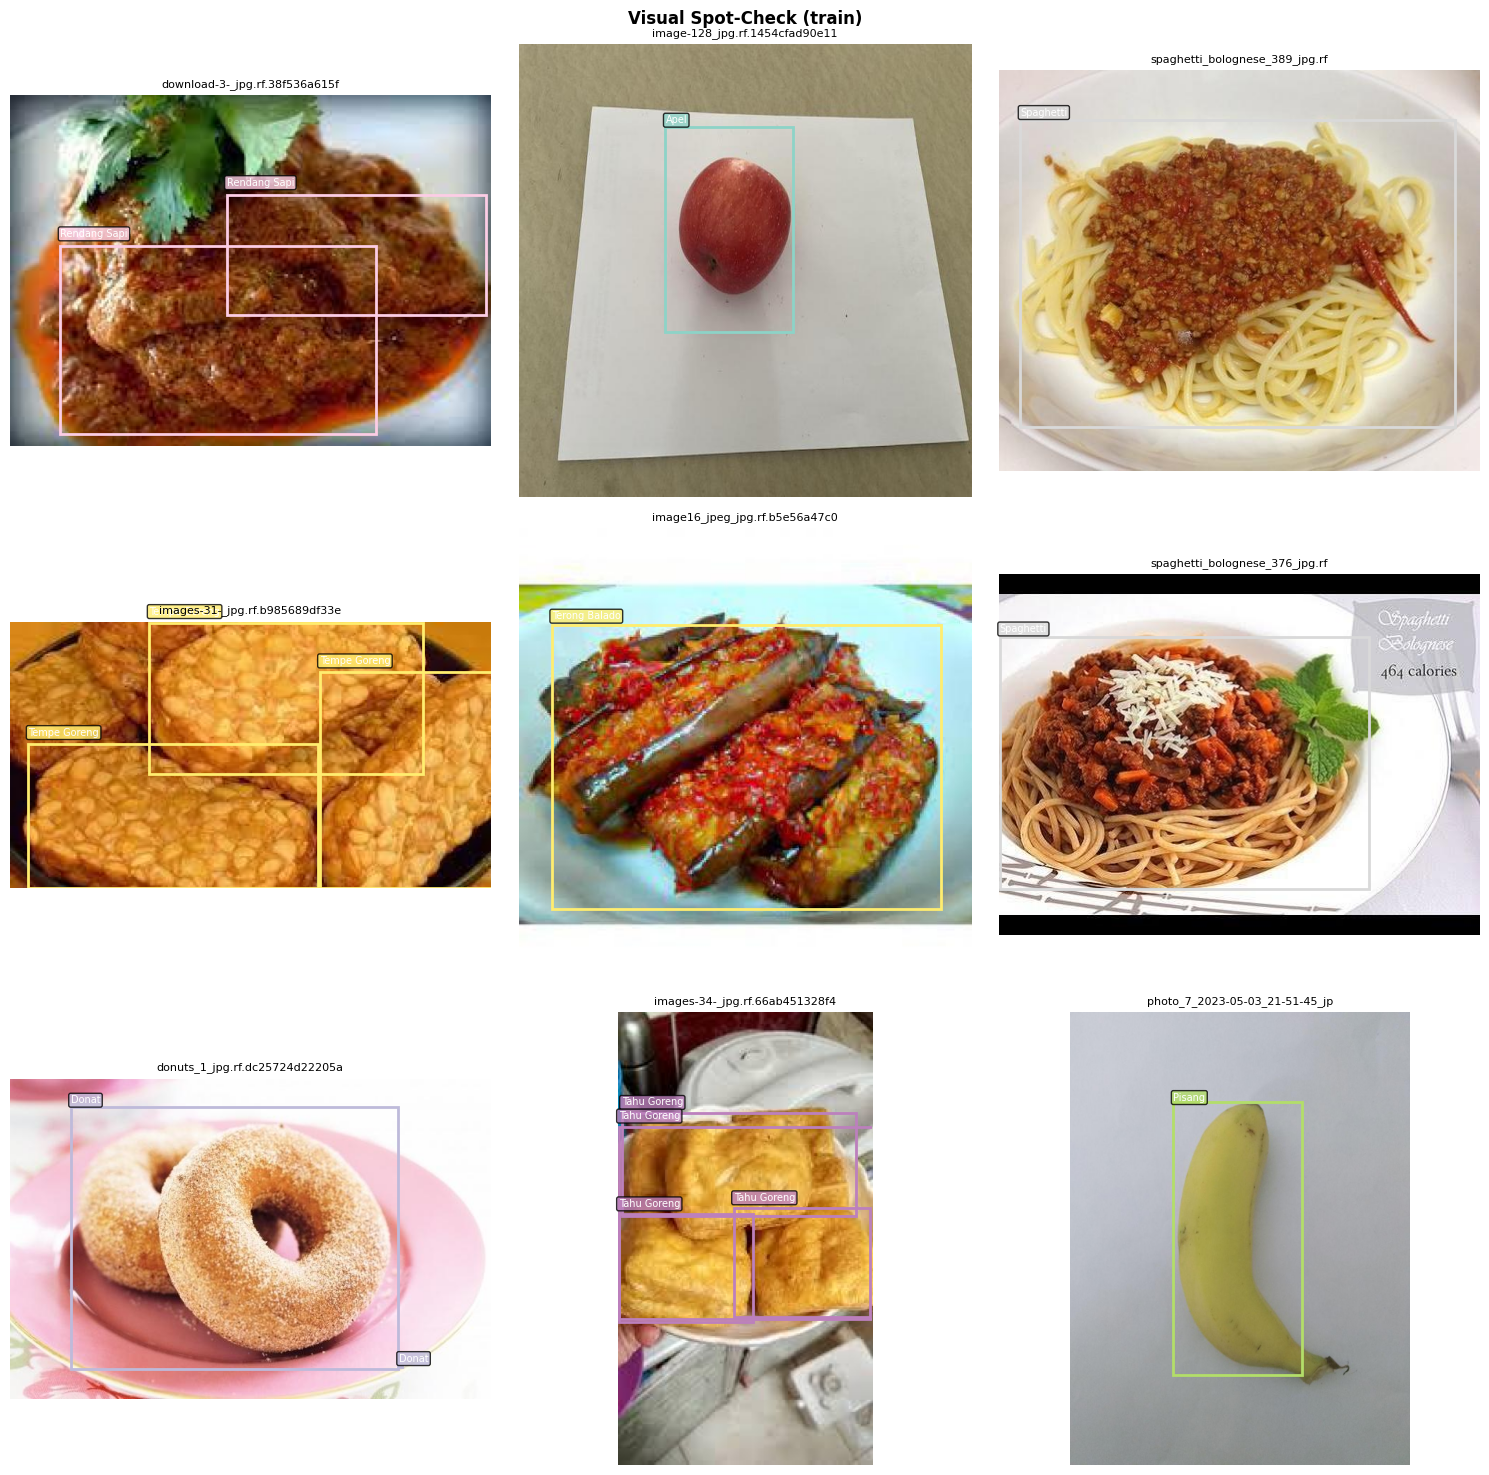

In [14]:
def plot_sample_with_bounding_boxes(yolo_dir, class_names, split='train', sample_count=6):
    """Tampilkan gambar acak dengan overlay bounding box."""
    image_dir = yolo_dir / 'images' / split
    label_dir = yolo_dir / 'labels' / split
    image_files = list(image_dir.glob('*.jpg'))

    np.random.seed(42)
    samples = np.random.choice(image_files, min(sample_count, len(image_files)), replace=False)

    columns = 3
    rows = int(np.ceil(len(samples) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(5 * columns, 5 * rows))
    axes = np.array(axes).flatten()
    color_palette = plt.cm.Set3(np.linspace(0, 1, len(class_names)))

    for idx, image_path in enumerate(samples):
        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_height, img_width = image.shape[:2]
        axes[idx].imshow(image)

        label_path = label_dir / (image_path.stem + '.txt')
        if label_path.exists():
            with open(label_path) as fh:
                for line in fh:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_c, y_c, b_w, b_h = [float(v) for v in parts[1:]]

                    x1 = (x_c - b_w / 2) * img_width
                    y1 = (y_c - b_h / 2) * img_height
                    box_w = b_w * img_width
                    box_h = b_h * img_height

                    color = color_palette[class_id % len(color_palette)]
                    rect = patches.Rectangle(
                        (x1, y1), box_w, box_h,
                        linewidth=2, edgecolor=color, facecolor='none'
                    )
                    axes[idx].add_patch(rect)
                    axes[idx].text(
                        x1, y1 - 5, class_names[class_id], fontsize=7, color='white',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.8)
                    )
        axes[idx].set_title(image_path.name[:30], fontsize=8)
        axes[idx].axis('off')

    for idx in range(len(samples), len(axes)):
        axes[idx].axis('off')

    plt.suptitle(f'Visual Spot-Check ({split})', fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / 'docs' / f'visual_spotcheck_{split}.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_sample_with_bounding_boxes(YOLO_DIR, class_names, split='train', sample_count=9)

---
## 7. Laporan Akhir

In [15]:
print("=" * 50)
print("LAPORAN AKHIR DATASET")
print("=" * 50)
print(f"Total gambar : {total_images}")
print(f"Total labels : {total_labels}")
print(f"Jumlah kelas : {len(class_names)}")
print(f"Format       : YOLO TXT (normalized xywh)")
print(f"Output       : {YOLO_DIR}")
print(f"Config       : {YOLO_DIR / 'data.yaml'}")
print(f"\nDataset siap untuk training YOLOv11.")

LAPORAN AKHIR DATASET
Total gambar : 3720
Total labels : 3720
Jumlah kelas : 29
Format       : YOLO TXT (normalized xywh)
Output       : d:\Dicoding Academy\DataCapstone\data_output\yolo_dataset
Config       : d:\Dicoding Academy\DataCapstone\data_output\yolo_dataset\data.yaml

Dataset siap untuk training YOLOv11.
